In [137]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
def jam_model(t, y, Λ, β, θ, γ, μ1, μ2):
    S, I, R = y
    dSdt = Λ - β * S * I - μ1 * S
    dIdt = (1 + θ) * β * S * I - (γ + μ2) * I
    dRdt = γ * I + μ1 * S + μ2 * I
    return [dSdt, dIdt, dRdt] 

In [ ]:
y0 = [392, 1589, 0]

Λ = 100   # Launch rate 
β = 1 / ( y0[0]* y0[1]) # Collision rate
θ = 18   # the number of fragments generated per S–I collision, in addition to the intact object that gets destroyed
γ = 0   # Mition rate (ADR/I) (active debris removal ADR currently 0 but this is where space debris missions could help)
μ1 = 10/y0[0]
μ2 = 8/y0[1] 

In [140]:
t_span = (0, 30)
t_eval = np.linspace(*t_span, 1000)

In [141]:
sol = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ, μ1, μ2), t_eval=t_eval)

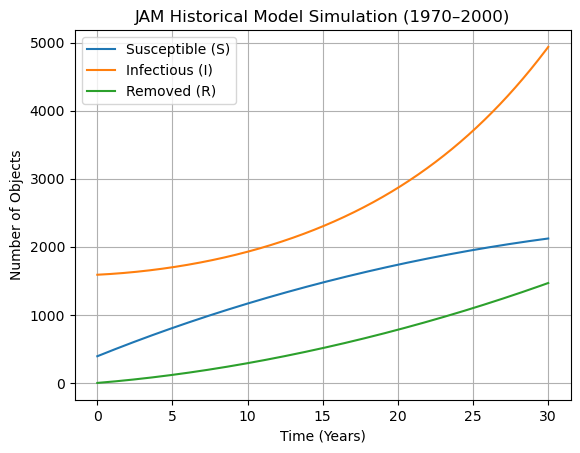

In [146]:
plt.plot(sol.t, sol.y[0], label='Susceptible (S)')
plt.plot(sol.t, sol.y[1], label='Infectious (I)')
plt.plot(sol.t, sol.y[2], label='Removed (R)')
plt.xlabel('Time (Years)')
plt.ylabel('Number of Objects')
plt.title('JAM Historical Model Simulation (1970–2000)')
plt.legend()
plt.grid(True)
plt.show()

In [143]:
t = sol.t
S = sol.y[0]
I = sol.y[1]
R = sol.y[2]

START_YEAR = 1970

In [144]:
df_jam = pd.DataFrame({
    "time": t,
    "S": S,
    "I": I,
    "R": R,
})

df_jam["year"] = START_YEAR + df_jam["time"]

df_jam.head()

,time,S,I,R,year
0,0.00000,392.000000,1589.000000,0.000000,1970.00000
1,0.03003,394.671544,1589.332310,0.541589,1970.03003
2,0.06006,397.340831,1589.668577,1.085274,1970.06006
3,0.09009,400.007863,1590.008802,1.631055,1970.09009
4,0.12012,402.672642,1590.352983,2.178929,1970.12012


In [145]:
df_jam.to_csv("jam_simulation_no_ADR_1970_start.csv", index=False)